In [ ]:
from data_utils import index_segmentations_df
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
from datetime import datetime
import os
import torch
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
import torch
from segmentation_preprocessing import preprocess_segmentations



from segmentation_training import SegmentationDataset, UNet

Load data

In [2]:
SEGMENTATIONS_DIR = Path.cwd().parents[2] / "AnnotationsData" / "Segmentations"


path_df = index_segmentations_df(
    SEGMENTATIONS_DIR,
    mask_name = 'calculated_masks'
)

mask_quality_df = pd.read_csv('mask_quality_summary.csv')
mask_quality_df = mask_quality_df[['image_path', 'mask_quality']]


mask_quality_df["image_path"] = mask_quality_df["image_path"].apply(Path)

path_df = path_df.merge(mask_quality_df, on = 'image_path', how = 'inner')
print(path_df.columns)

# Only segment the entire cell ie. not just the SOMA
path_df = path_df[path_df['class'] == 'MG_whole']
# Remove all bad annotations
path_df = path_df[~path_df['mask_quality'].isin(['bad', 'bad_image_quality', 'disagree'])]

# path_df = path_df.merg(mask_quality_df, on = )
# Only take first 100 for now to train fast
# path_df = path_df.head(160)
print(len(path_df), "annotation pairs found")


    # First split: train + temp (val+test)
train_df, temp_df = train_test_split(
    path_df,
    test_size=0.3,        # 70% train, 30% temp
    random_state=42,
    shuffle=True
)

# Second split: val + test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,        # 15% val, 15% test
    random_state=42,
    shuffle=True
)

print('Training, validatoin and testing sizes')
print(len(train_df), len(val_df), len(test_df))



train_tfms = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    ToTensorV2()
])

test_tfms = A.Compose([
    A.Resize(256, 256),
    ToTensorV2()
])



train_ds = SegmentationDataset(train_df, train_tfms)
test_ds  = SegmentationDataset(test_df, test_tfms)
val_ds = SegmentationDataset(val_df, test_tfms)


train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=0)


criterion = nn.BCEWithLogitsLoss()
# criterion = DiceLoss()

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'currently using device: {device}')

Index(['scan', 'class', 'image_path', 'mask_path', 'mask_quality'], dtype='object')
967 annotation pairs found
Training, validatoin and testing sizes
676 145 146
currently using device: cpu


Load model from path

In [3]:
model = UNet().to(device)

checkpoint_path = Path("checkpoints") / "best_run_25_1.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))

model.eval()  # important for inference / evaluation
print(f"Loaded model weights from {checkpoint_path}")




Loaded model weights from checkpoints\best_run_25_1.pth


C:\Users\chris\AppData\Local\Temp\ipykernel_36052\3561805482.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_locati

In [ ]:
# import torch
# import torch.nn.functional as F

# def graph_smooth_mask(
#     prob_mask: torch.Tensor,
#     num_iters: int = 5,
#     alpha: float = 0.8,
#     threshold: float = 0.5
# ):
#     """
#     Graph-style smoothing via iterative neighborhood agreement.

#     Args
#     ----
#     prob_mask : torch.Tensor
#         (H, W) or (1, H, W), values in [0,1]
#     num_iters : int
#         Number of smoothing iterations
#     alpha : float
#         Weight for original prediction (0.6–0.9 works well)
#     threshold : float
#         Threshold for final binarization

#     Returns
#     -------
#     smoothed_mask : torch.Tensor
#         (H, W) binary mask
#     """

#     if prob_mask.dim() == 2:
#         prob_mask = prob_mask.unsqueeze(0)

#     prob = prob_mask.clone()

#     # 3x3 averaging kernel (local graph neighborhood)
#     kernel = torch.ones(1, 1, 3, 3, device=prob.device) / 9.0

#     for _ in range(num_iters):
#         neighbor_avg = F.conv2d(
#             prob.unsqueeze(0), kernel, padding=1
#         ).squeeze(0)

#         # Unary + pairwise update
#         prob = alpha * prob + (1 - alpha) * neighbor_avg
#         prob = prob.clamp(0, 1)

#     return (prob > threshold).float().squeeze(0)


In [ ]:
import torch
import torch.nn.functional as F

def connect_positive_components(
    prob_mask: torch.Tensor,
    threshold: float = 0.5,
    grow_threshold: float = 0.17,
    num_iters: int = 15
):
    """
    Connect positive regions by growing them through high-probability paths.
    Never removes existing positives.

    Args
    ----
    prob_mask : torch.Tensor
        (H, W) or (1, H, W), values in [0,1]
    threshold : float
        Initial foreground threshold
    grow_threshold : float
        Minimum probability to allow growth through
    num_iters : int
        How aggressively to try connecting components

    Returns
    -------
    connected_mask : torch.Tensor
        (H, W) binary mask
    """

    if prob_mask.dim() == 2:
        prob_mask = prob_mask.unsqueeze(0)

    # Initial hard positives (LOCKED IN)
    mask = (prob_mask > threshold).float()

    # Allowed growth region
    grow_region = (prob_mask > grow_threshold).float()

    kernel = torch.ones(1, 1, 3, 3, device=prob_mask.device)

    for _ in range(num_iters):
        # Dilate current positives
        dilated = F.conv2d(
            mask.unsqueeze(0), kernel, padding=1
        ).squeeze(0) > 0

        # Only grow into allowed region
        new_mask = torch.logical_and(dilated, grow_region)

        # IMPORTANT: only ADD pixels, never remove
        mask = torch.logical_or(mask.bool(), new_mask).float()

    return mask.squeeze(0)


In [30]:
@torch.no_grad()
def visualize_predictions(
    model,
    loader,
    device,
    num_samples=3,
    threshold=0.5,
    smooth_iters=10,
    smooth_alpha=0.4
):
    model.eval()

    x, y = next(iter(loader))
    x, y = x.to(device), y.to(device)

    logits = model(x)
    probs = torch.sigmoid(logits)  # (B, 1, H, W)

    for i in range(min(num_samples, x.size(0))):
        img = x[i].cpu().permute(1, 2, 0)
        gt  = y[i, 0].cpu()

        # Raw prediction
        raw_prob = probs[i, 0]
        raw_pred = (raw_prob > threshold).float()

        # Graph-smoothed prediction (IMPORTANT: per-sample)
        smooth_pred = connect_positive_components(
            raw_prob,              # <- single (H, W) tensor
            threshold=threshold,
            grow_threshold=0.17,
            num_iters=15
        )


        plt.figure(figsize=(16, 4))

        plt.subplot(1, 4, 1)
        plt.imshow(img)
        plt.title("Input image")
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.imshow(gt, cmap="gray")
        plt.title("Ground truth")
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.imshow(raw_pred, cmap="gray")
        plt.title("Raw prediction")
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.imshow(smooth_pred, cmap="gray")
        plt.title("Graph-smoothed")
        plt.axis("off")

        plt.tight_layout()
        plt.show()


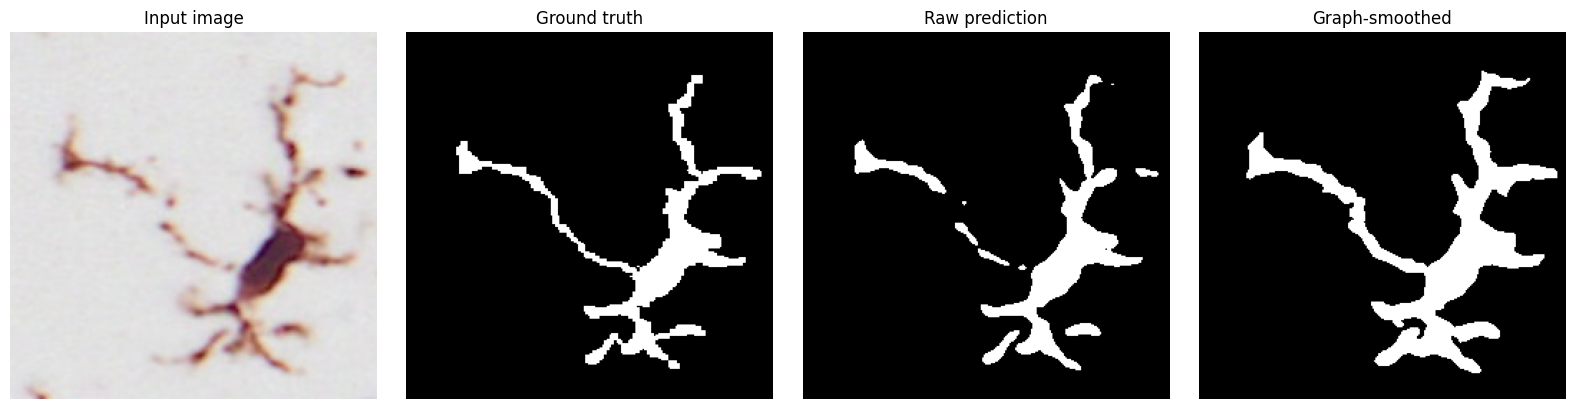

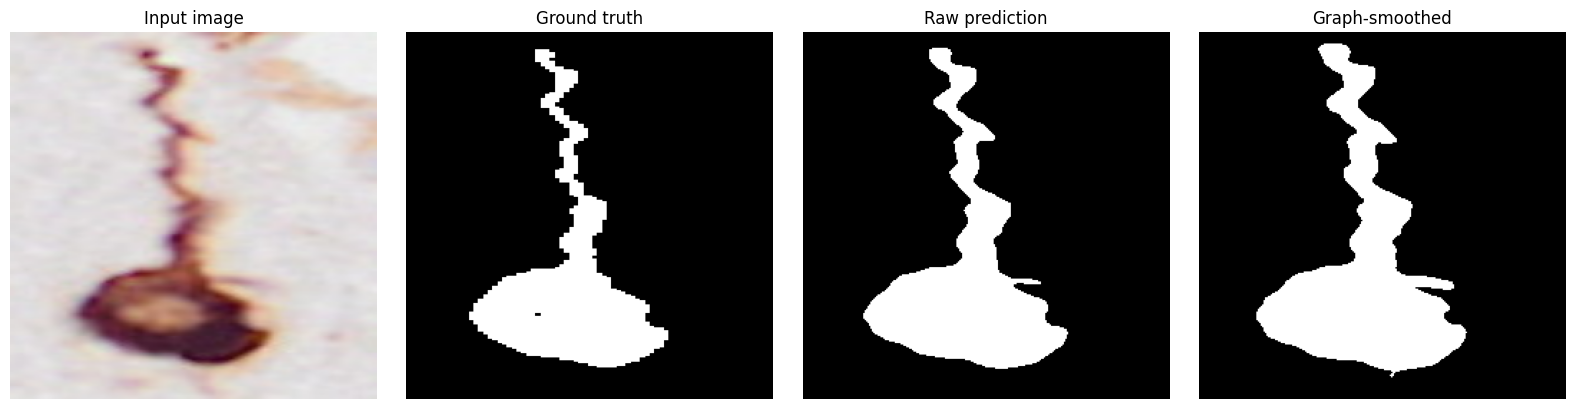

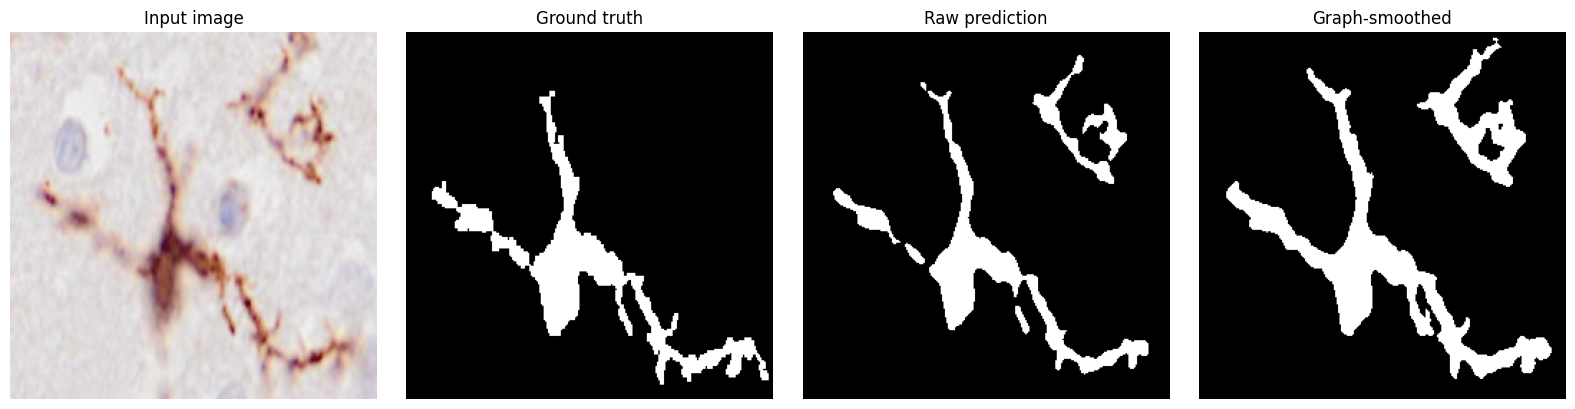

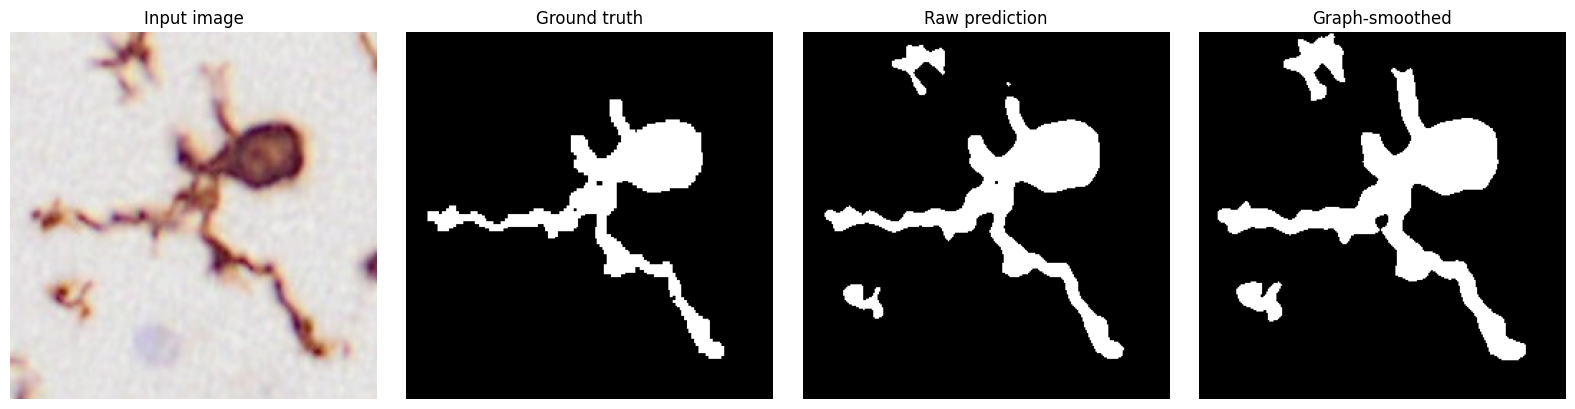

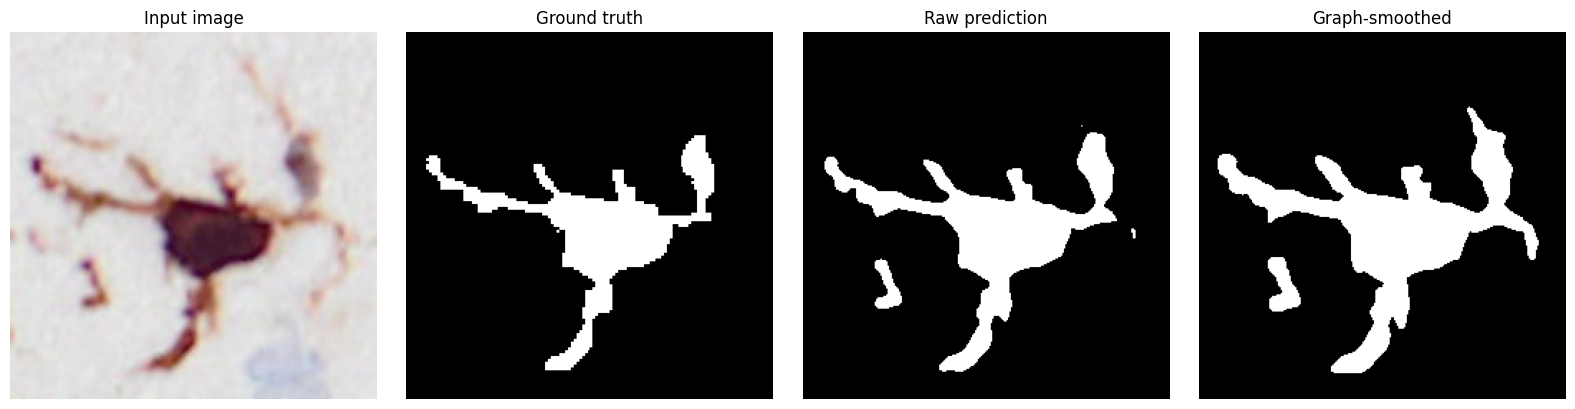

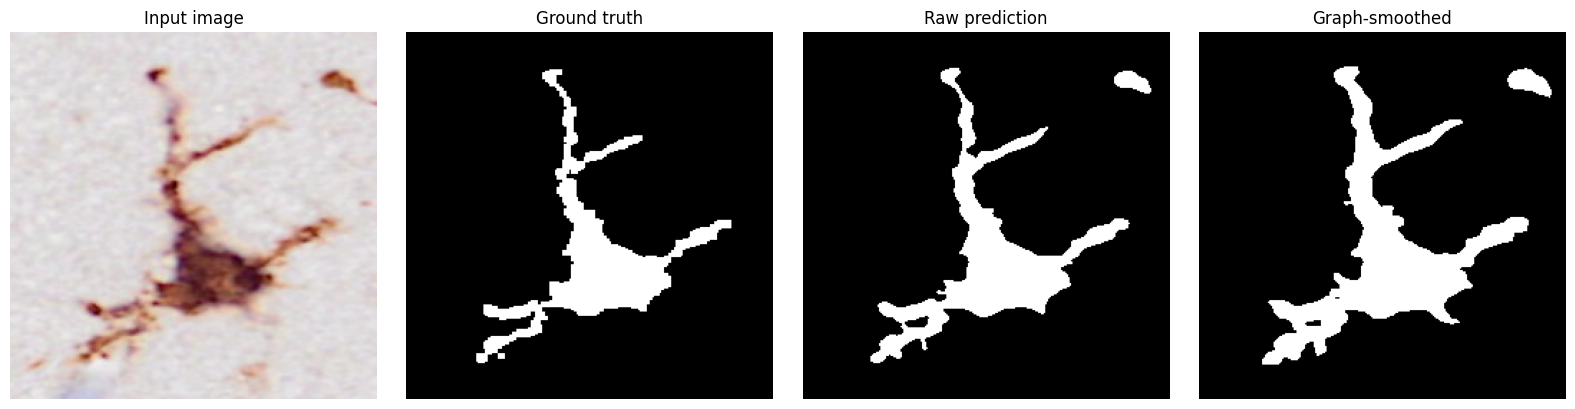

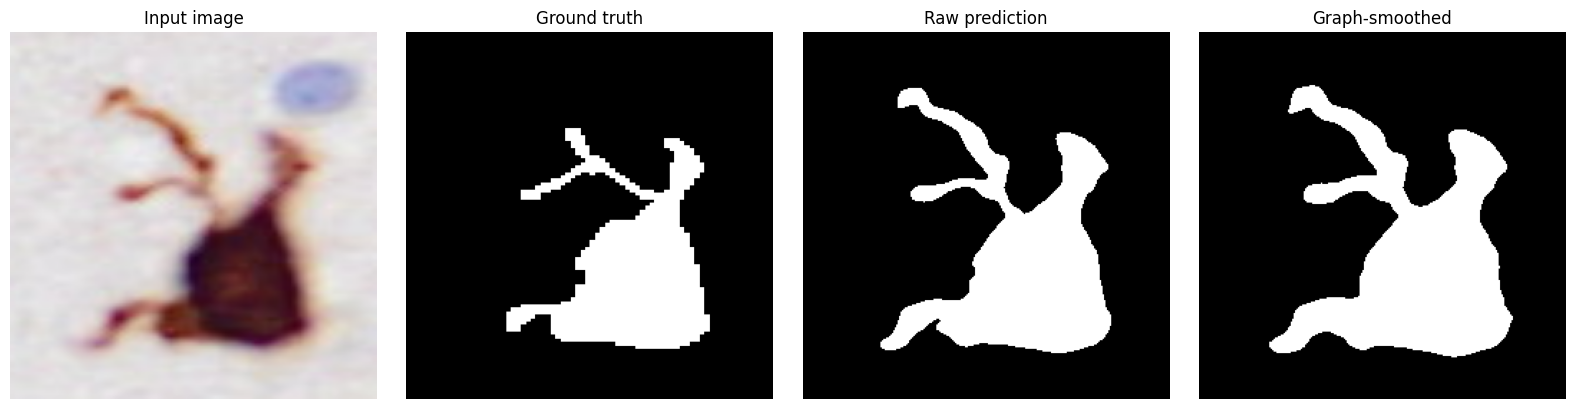

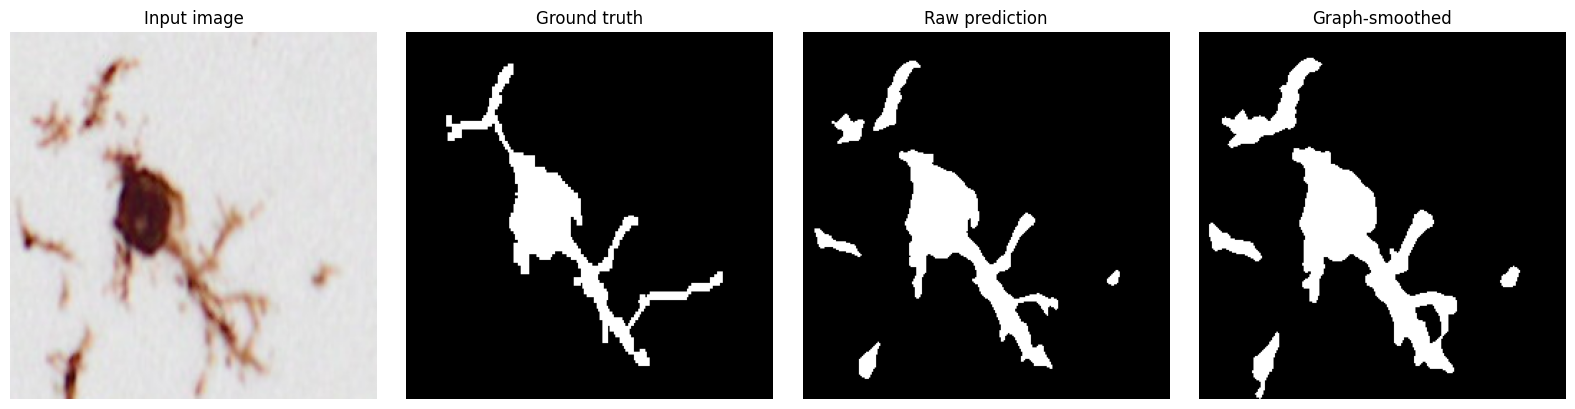

In [31]:
visualize_predictions(
    model,
    test_loader,
    device,
    num_samples=8,
    threshold=0.5
)